Chapter 31
# 从几何角度理解PCA
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

◄ sklearn.preprocessing.StandardScaler() 用于对数据进行标准化处理

◄ sklearn.decomposition.PCA() 执行主成分分析 PCA 以减少数据维度

◄ sklearn.covariance.EmpiricalCovariance() 计算基于样本的经验协方差矩阵


In [2]:
# 导入包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as pdr
# pip install pandas_datareader
import seaborn as sns

# 下载数据

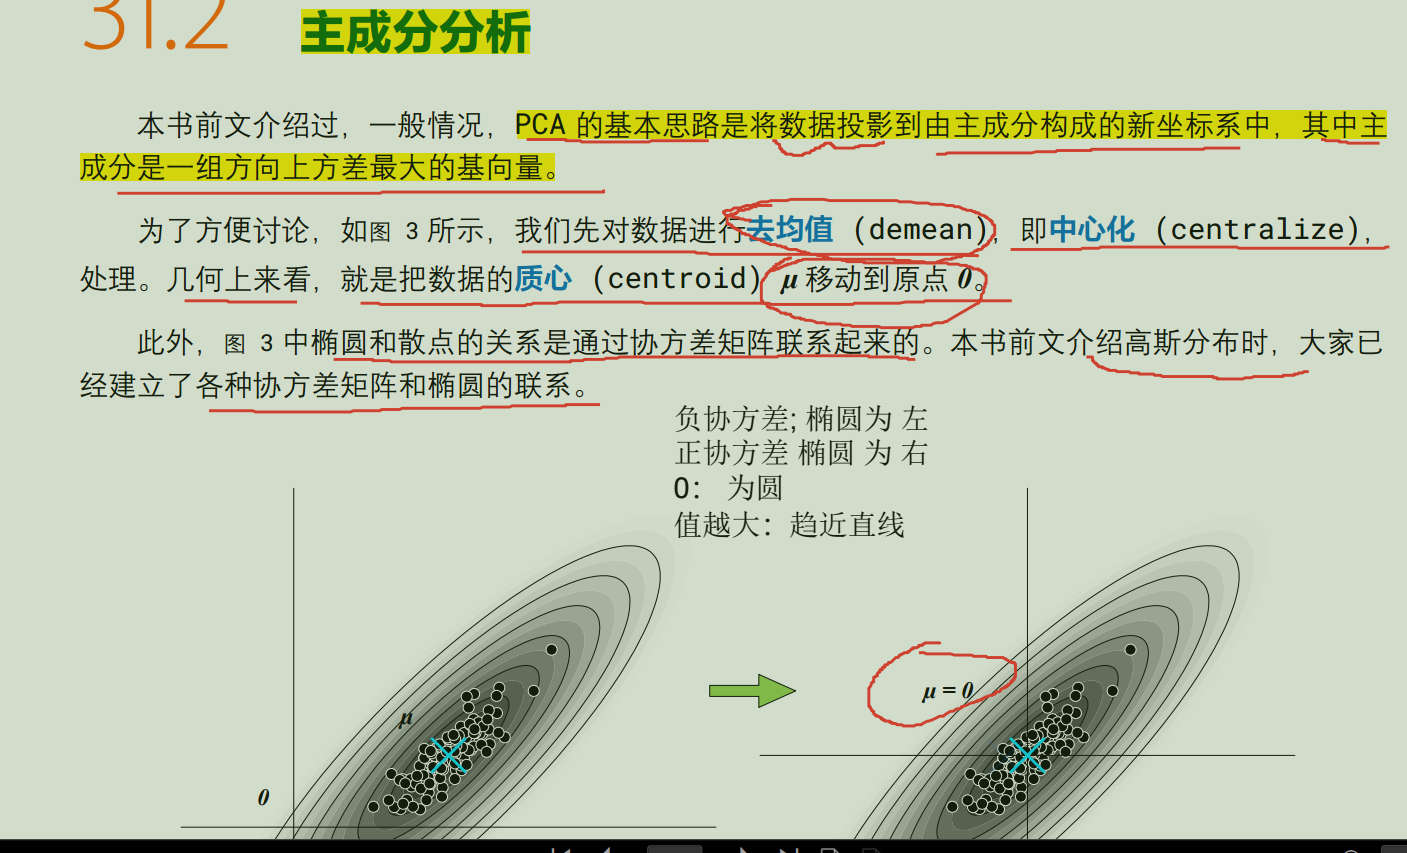

在进行 PCA 前一般要对数据进行标准化 (standardization)。标准化可以消
除数据不同特征尺度不同的影响，标准化过程还完成了去单位化，每个特征数据都变成了 Z 分数。

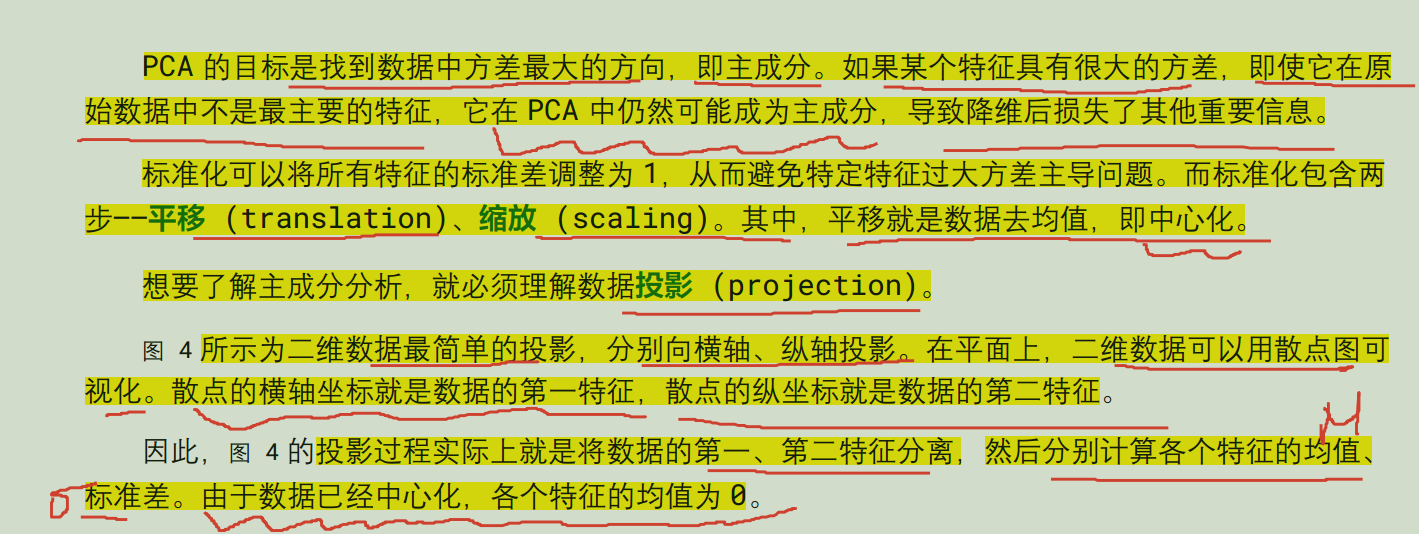

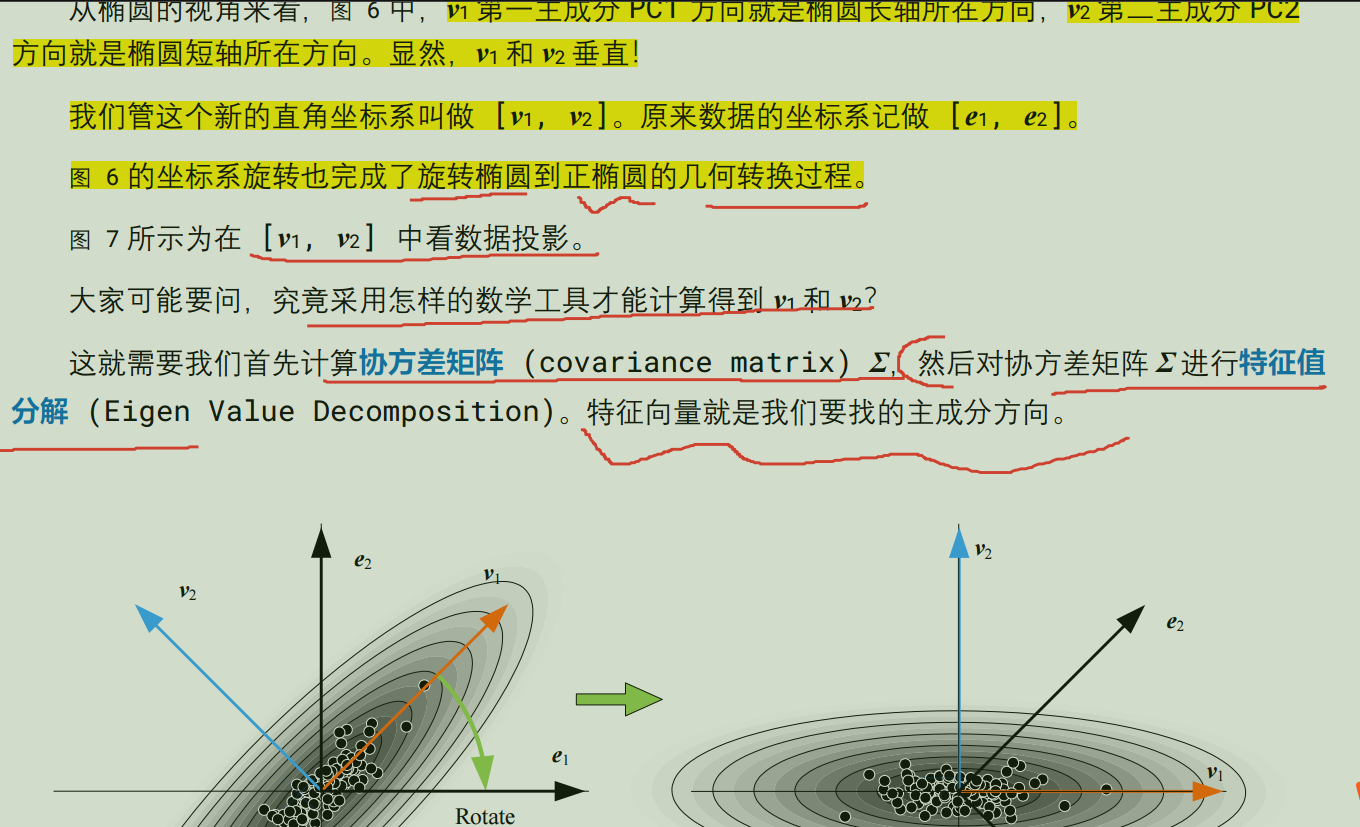

此外，除了特征值分解协方差矩阵，还有其他不同的主成分分析技术路线。鸢尾花书《数据有
道》会专门比较不同技术路线的异同。
虽然，我们不会具体介绍计算协方差、特征值分解背后的数学工具，以及这两个工具和椭圆的联
系；但是大家可能已经发现，想要深入理解主成分分析，离不开概率统计、线性代数、几何这些视角。
这都是鸢尾花“数学三剑客”要介绍的内容。
在主成分分析中，主成分通常是原始特征的线性组合。也就是说，PCA 是一种线性降维方法，它只
能捕捉数据中的线性相关性。如果数据具有复杂的非线性关系，PCA 可能无法很好地捕捉这些模式，从
而导致信息丢失。

核主成分分析 (Kernel Principal Component Analysis)，也叫核 PCA，在高维特征空间
中使用核技巧 (kernel trick) 来进行 PCA，从而能够处理非线性关系。
核 PCA 可以解决传统 PCA 无法处理的非线性问题。在处理非线性数据时，传统 PCA 可能会损失数
据的重要信息，因为它只能发现线性关系。
核 PCA 通过将数据映射到高维特征空间，将数据从原始空间中的非线性关系转化为高维空间中的线
性关系，因此可以有效地保留数据的非线性结构信息。
与传统的主成分分析不同，核 PCA 不直接使用原始数据来计算主成分，而是通过将数据映射到高维
特征空间来获取主成分。核技巧的基本思想是通过核函数 (kernel function) 将数据映射到高维
特征空间中，从而使得线性模型能够处理非线性数据。
常用的核函数包括，径向基核函数 (radial basis function kernel, RBF kernel)，也
叫高斯核函数，多项式核 (polynomial kernel)，Sigmoid 核 (Sigmoid kernel)。我们在本
书第 32 章讲解支持向量机 (Support Vector Machine, SVM) 还会用到核技巧。本书不展开讲解
核主成分分析。


In [6]:
# 下载数据
df = pdr.data.DataReader(['DGS6MO','DGS1'],  # 数据名
                          data_source='fred',
                          start='01-01-2022',  # 时间

                        end='12-31-2022')
print(df)
print(df.shape)

df.to_csv('IR_data.csv') # 保存为csv文件
# 如果不能下载数据，请用pandas.read_csv() 读入配套数据
df = df.dropna() # 删除缺失值
print(df.shape)

            DGS6MO  DGS1
DATE                    
2022-01-03    0.22  0.40
2022-01-04    0.22  0.38
2022-01-05    0.22  0.41
2022-01-06    0.23  0.45
2022-01-07    0.24  0.43
...            ...   ...
2022-12-26     NaN   NaN
2022-12-27    4.76  4.75
2022-12-28    4.75  4.71
2022-12-29    4.73  4.71
2022-12-30    4.76  4.73

[260 rows x 2 columns]
(260, 2)
(249, 2)


观察形状可知；有缺失值

In [5]:
df

,DGS6MO,DGS1
DATE,,
2022-01-03,0.22,0.40
2022-01-04,0.22,0.38
2022-01-05,0.22,0.41
2022-01-06,0.23,0.45
2022-01-07,0.24,0.43
...,...,...
2022-12-23,4.67,4.66
2022-12-27,4.76,4.75
2022-12-28,4.75,4.71


## 修改列标签

In [7]:
# 修改列标签
df = df.rename(columns={'DGS6MO': 'X1',
                        'DGS1': 'X2'})
df.head()

,X1,X2
DATE,,
2022-01-03,0.22,0.40
2022-01-04,0.22,0.38
2022-01-05,0.22,0.41
2022-01-06,0.23,0.45
2022-01-07,0.24,0.43


## 计算日收益率

In [8]:
X_df = df.pct_change();
print(X_df)
print(X_df.shape)
# 计算日收益率
X_df = X_df.dropna()
print(X_df.shape)
print(X_df)


                  X1        X2
DATE                          
2022-01-03       NaN       NaN
2022-01-04  0.000000 -0.050000
2022-01-05  0.000000  0.078947
2022-01-06  0.045455  0.097561
2022-01-07  0.043478 -0.044444
...              ...       ...
2022-12-23  0.002146  0.004310
2022-12-27  0.019272  0.019313
2022-12-28 -0.002101 -0.008421
2022-12-29 -0.004211  0.000000
2022-12-30  0.006342  0.004246

[249 rows x 2 columns]
(249, 2)
(248, 2)
                  X1        X2
DATE                          
2022-01-04  0.000000 -0.050000
2022-01-05  0.000000  0.078947
2022-01-06  0.045455  0.097561
2022-01-07  0.043478 -0.044444
2022-01-10  0.166667  0.069767
...              ...       ...
2022-12-23  0.002146  0.004310
2022-12-27  0.019272  0.019313
2022-12-28 -0.002101 -0.008421
2022-12-29 -0.004211  0.000000
2022-12-30  0.006342  0.004246

[248 rows x 2 columns]




```

步骤	方法	作用
①	fit()	计算 X_df 每个特征的均值和标准差
②	transform()	用这些统计量对数据进行转换：(x - mean) / std
```



In [11]:
from sklearn.preprocessing import StandardScaler # 标准化
scaler = StandardScaler()
print(scaler)
X_scaled = scaler.fit_transform(X_df) #
print(X_scaled.shape)
print(X_scaled[:3])

StandardScaler()
(248, 2)
[[-0.30527131 -1.54857077]
 [-0.30527131  1.73886783]
 [ 0.73259377  2.21341098]]


In [13]:
X_scaled.T.shape

(2, 248)

In [15]:
X_scaled.T[:3, :3]

array([[-0.30527131, -0.30527131,  0.73259377],
       [-1.54857077,  1.73886783,  2.21341098]])

# 计算协方差矩阵

In [16]:
np.cov(X_scaled.T)

array([[1.00404858, 0.74432704],
       [0.74432704, 1.00404858]])

##生成网格数据

In [17]:
from sklearn.covariance import EmpiricalCovariance #计算协方差矩阵
x1_array = np.linspace(-6,6,601)
x2_array = np.linspace(-6,6,601)
xx1, xx2 = np.meshgrid(x1_array, x2_array)

# 转为一维数组按列排序每行就是一个点（坐标）
xx12 = np.c_[xx1.ravel(), xx2.ravel()]

## 计算数据的协方差矩阵

In [18]:
COV = EmpiricalCovariance().fit(X_scaled) # 计算数据的协方差矩阵

In [19]:
COV

EmpiricalCovariance()

In [20]:
COV.covariance_

array([[1.        , 0.74132572],
       [0.74132572, 1.        ]])

## 计算网格化数据的马氏距离


In [24]:
mahal_sq_Xc = COV.mahalanobis(xx12) # 计算网格点的马氏距离

In [25]:
mahal_sq_Xc

array([41.34780716, 41.21086916, 41.07570722, ..., 41.07570722,
       41.21086916, 41.34780716])

In [26]:
mahal_sq_Xc.shape

(361201,)

输出的结果为马氏距离的平方。 f
开平方后获得马氏距离。

根据样本协方差矩阵计算网格化数据的马氏距离平方值。这里需要大家格外注意，

网格数据点应
该与原始数据集 X_scaled 具有相同的特征维度 (两列)。这就是为什么我们需要用
e
调整马数组形
状，以便后续可视化。


此外，大家需要注意，输出的结果为马氏距离的平方。 f
开平方后获得马氏距离。


In [27]:
mahal_sq_dd = mahal_sq_Xc.reshape(xx1.shape) # 将数据转为 601*601
mahal_dd = np.sqrt(mahal_sq_dd) # 进行开方

In [28]:
mahal_dd

array([[ 6.43022606,  6.41956924,  6.40903325, ..., 16.6279962 ,
        16.65579183, 16.68359437],
       [ 6.41956924,  6.40879197,  6.39813535, ..., 16.60017986,
        16.62798239, 16.65579183],
       [ 6.40903325,  6.39813535,  6.38735788, ..., 16.57237041,
        16.60017986, 16.6279962 ],
       ...,
       [16.6279962 , 16.60017986, 16.57237041, ...,  6.38735788,
         6.39813535,  6.40903325],
       [16.65579183, 16.62798239, 16.60017986, ...,  6.39813535,
         6.40879197,  6.41956924],
       [16.68359437, 16.65579183, 16.6279962 , ...,  6.40903325,
         6.41956924,  6.43022606]])

In [29]:
mahal_dd.shape

(601, 601)

# 绘制图像

In [22]:
X_scaled[:10]

array([[-0.30527131, -1.54857077],
       [-0.30527131,  1.73886783],
       [ 0.73259377,  2.21341098],
       [ 0.6874692 , -1.40693509],
       [ 3.500234  ,  1.50483091],
       [-0.30527131, -0.27384968],
       [-1.12073673,  0.83460344],
       [ 0.54039654, -0.80498347],
       [ 1.32565953,  1.89588834],
       [ 5.02243612,  3.22538468]])

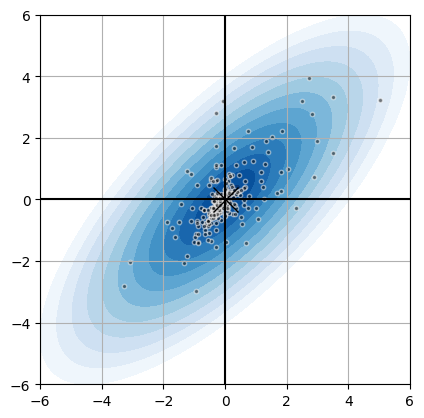

In [30]:
fig, ax = plt.subplots()

#  绘制马氏距离填充等高线
#  等高线的数量；均匀分布
plt.contourf(xx1, xx2, mahal_dd,
             cmap='Blues_r', levels=np.linspace(0,6,13))

#  绘制样本数据 (标准化) 散点图
#  第一二列数据
# s：点的大小；edgecolor;边缘颜色 marker：标记
plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38, edgecolor = 'w', alpha = 0.5,
            marker = '.', color = 'k')
# 绘制样本数据质心
# 每个特征的均值
plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',
         color = 'k',
         markersize = 18)
# 绘制坐标轴
ax.axvline(x = 0, c = 'k')
ax.axhline(y = 0, c = 'k')
ax.grid('off') # 关闭坐标轴上的网格线
ax.set_aspect('equal', adjustable='box') # 比例一致
ax.set_xbound(lower = -6, upper = 6) # 约束
ax.set_ybound(lower = -6, upper = 6)

## 绘制图像2

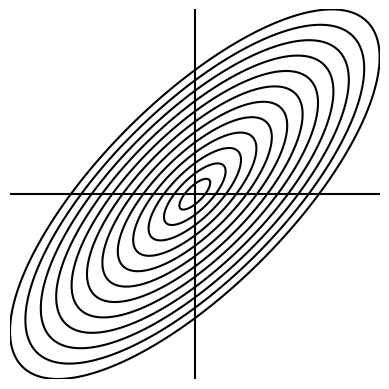

In [31]:
fig, ax = plt.subplots()

# 等高线；没有填充
plt.contour(xx1, xx2, mahal_dd,
            colors='k', levels=np.linspace(0,6,13))

ax.axvline(x = 0, c = 'k')
ax.axhline(y = 0, c = 'k')
ax.set_xticks([]) # 不显示刻度
ax.set_yticks([])
ax.axis('off')
ax.set_aspect('equal', adjustable='box')
ax.set_xbound(lower = -6, upper = 6)
ax.set_ybound(lower = -6, upper = 6)

## 主成分分析

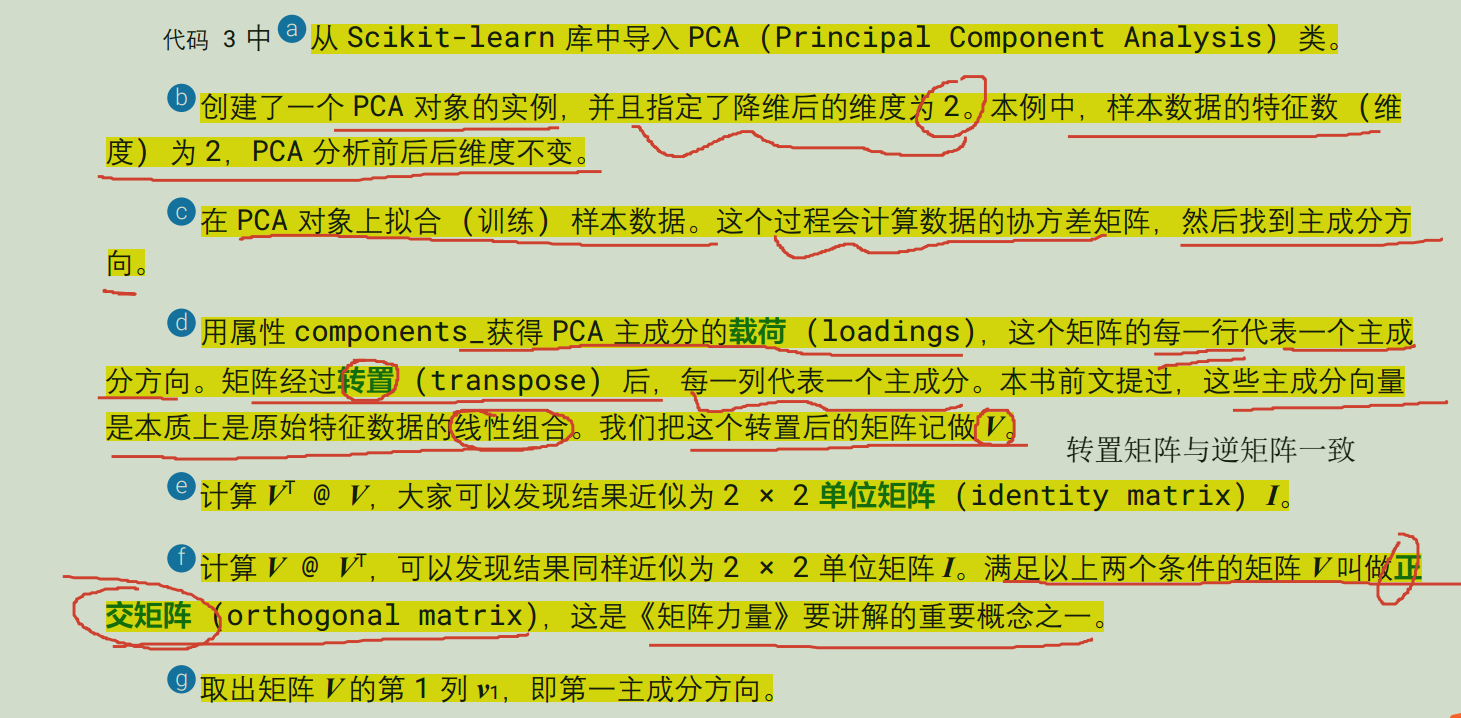

In [32]:
from sklearn.decomposition import PCA

# 主成分分析
n_components = 2 # 主成分数量
pca = PCA(n_components=2)
print(f"pac: {pca}")
# 拟合PCA模型
pca.fit(X_scaled)

# 获取loadings（主成分方向向量）
# 用属性components_获得 PCA 主成分的载荷 (loadings)，
'''
这个矩阵的每一行代表一个主成
分方向。矩阵经过转置 (transpose) 后，每一列代表一个主成分。
本书前文提过，这些主成分向量是本质上是原始特征数据的线性组合。我们把这个转置后的矩阵记做 V。
'''
print(f"pca.components_: {pca.components_}")
loadings = pca.components_.T
print(f"loadings: {loadings}")
V = loadings
print(np.round(loadings.T @ loadings))
print(np.round(V @ V.T))
v1 = V[:,[0]] # 第一主成分方向
v2 = V[:,[1]] # 第二主成分方向

pac: PCA(n_components=2)
pca.components_: [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
loadings: [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
[[ 1. -0.]
 [-0.  1.]]
[[ 1. -0.]
 [-0.  1.]]


In [33]:
print(v1) # 第一列
print(v2) # 第二列

[[0.70710678]
 [0.70710678]]
[[ 0.70710678]
 [-0.70710678]]


#这两个属性都是 PCA（主成分分析）中衡量主成分重要性的指标，但含义和用途不同

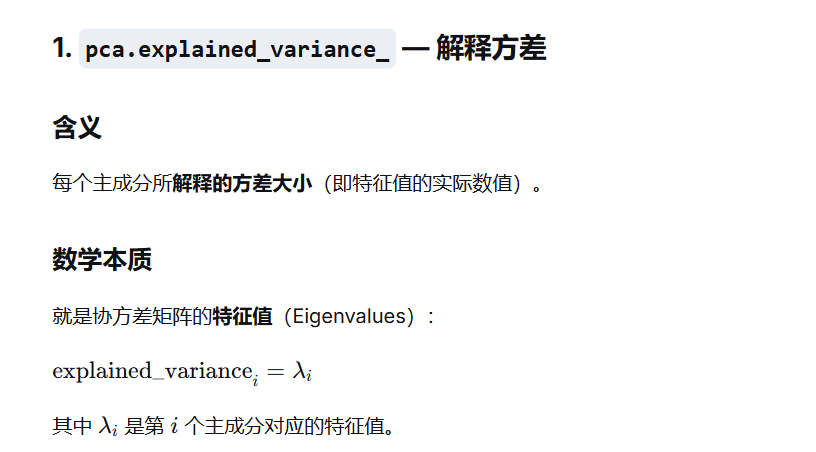

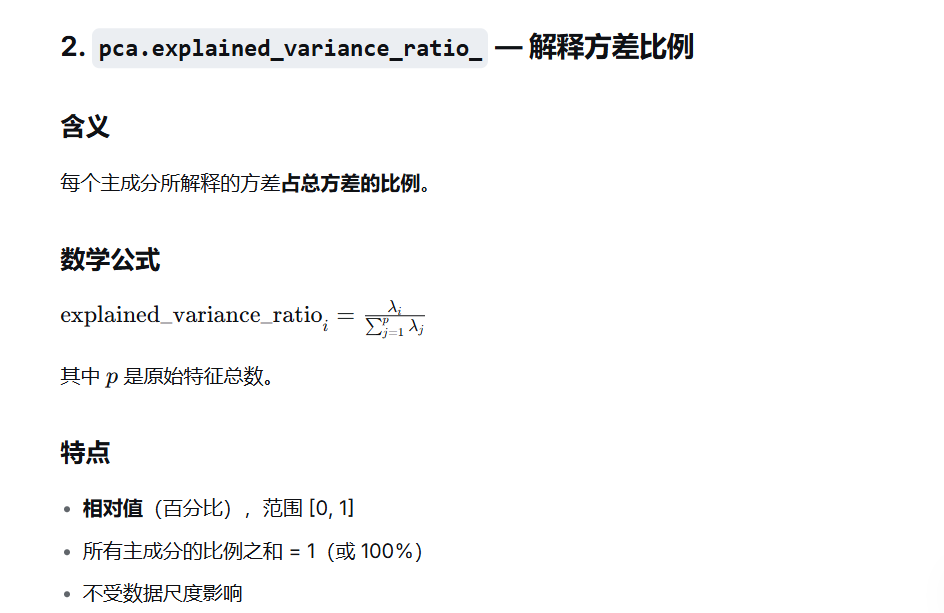

In [36]:
pca.explained_variance_ #每个主成分所解释的方差大小（即特征值的实际数值）。

array([1.74837562, 0.25972155])

In [37]:
pca.explained_variance_ratio_ # 解释方差比例 # 总数为1

array([0.87066286, 0.12933714])

##自定义绘制向量函数

angles='xy'角度基于数据坐标箭头方向与坐标轴单位一致


scale_units='xy'缩放单位基于数据坐标确保长度不受图形尺寸影响


scale=1缩放比例为1不缩放，显示实际长度


color=RBG用户指定颜色设置箭头颜色


zorder=1e5极大层级值确保箭头绘制在最上层（覆盖其他图形）

zip(*array) 将二维数组转置，从 (1,4) 变为 (4,1)

解包得到 4 个单元素元组：

X = (0,)

Y = (0,)

U = (vector[0],)

V = (vector[1],)

In [38]:
# 自定义绘制向量函数
def draw_vector(vector,RGB):
    array = np.array([[0, 0, vector[0], vector[1]]], dtype=object)
    X, Y, U, V = zip(*array)
    plt.quiver(X, Y, U, V,angles='xy',
               scale_units='xy',scale=1,color = RGB,
               zorder = 1e5)

##绘制图像

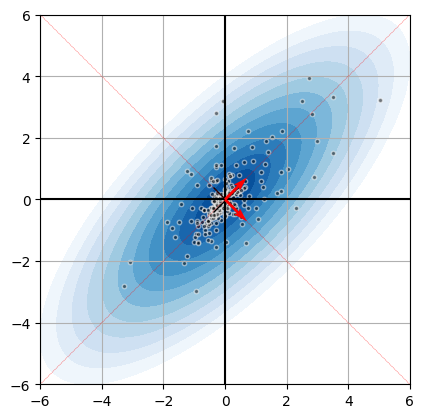

In [39]:
fig, ax = plt.subplots()

# 绘制马氏距离等高线
plt.contourf(xx1, xx2, mahal_dd,
             cmap='Blues_r', levels=np.linspace(0,6,13))
# # 绘制标准化数据散点图
plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38, edgecolor = 'w', alpha = 0.5,
            marker = '.', color = 'k')
# 绘制质心
plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',
         color = 'k',
         markersize = 18)
# 可视化两个主成分方向
# v1;v2向量
draw_vector(v1,'r')
draw_vector(v2,'r')

# 绘制两条参考线；v1[1]/v1[0]斜率
ax.plot(x1_array,x1_array*v1[1]/v1[0], 'r',
        lw = 0.25, ls = 'dashed')
ax.plot(x1_array,x1_array*v2[1]/v2[0], 'r',
        lw = 0.25, ls = 'dashed')
# 坐标轴
ax.axvline(x = 0, c = 'k'); ax.axhline(y = 0, c = 'k')
ax.grid('off')
ax.set_aspect('equal', adjustable='box') #x,y轴比例一致
ax.set_xbound(lower = -6, upper = 6); ax.set_ybound(lower = -6, upper = 6) # 约束

In [44]:
v1

array([[0.70710678],
       [0.70710678]])

In [45]:
v1@v1.T

array([[0.5, 0.5],
       [0.5, 0.5]])

In [40]:
# 完成投影
proj1 = v1@v1.T

z1_2D = X_scaled@proj1

In [41]:
proj1

array([[0.5, 0.5],
       [0.5, 0.5]])

In [43]:
z1_2D.shape

(248, 2)

## 绘制图像

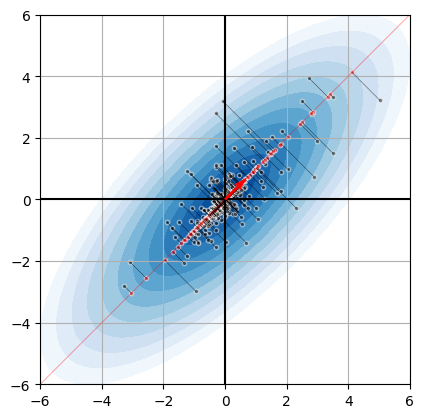

In [46]:
fig, ax = plt.subplots()

# 等高线（填充）
plt.contourf(xx1, xx2, mahal_dd,
             cmap='Blues_r', levels=np.linspace(0,6,13))
# 原始数据的散点图
plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38, edgecolor = 'w', alpha = 0.5,
            marker = '.', color = 'k')

plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',
         color = 'k',
         markersize = 18)
# 散点图 z1_2D：原始数据在v1的投影
plt.scatter(z1_2D[:,0],z1_2D[:,1],
            s = 38, edgecolor = 'w', alpha = 0.5,
            marker = '.', color = 'r')
# 连接原始数据 与 v1方向的值
plt.plot(([i for (i,j) in z1_2D], [i for (i,j) in X_scaled]),
         ([j for (i,j) in z1_2D], [j for (i,j) in X_scaled]),
         c='k', lw = 0.25)
# 画向量
draw_vector(v1,'r')
# 参考线
ax.plot(x1_array,x1_array*v1[1]/v1[0], 'r', lw = 0.25)

ax.axvline(x = 0, c = 'k')
ax.axhline(y = 0, c = 'k')
ax.grid('off')
ax.set_aspect('equal', adjustable='box')
ax.set_xbound(lower = -6, upper = 6)
ax.set_ybound(lower = -6, upper = 6)

In [51]:
v2.shape

(2, 1)

In [47]:
# 完成投影
proj2 = v2@v2.T

z2_2D = X_scaled@proj2

In [48]:
proj2

array([[ 0.5, -0.5],
       [-0.5,  0.5]])

In [49]:
z2_2D.shape

(248, 2)

## 绘制图形

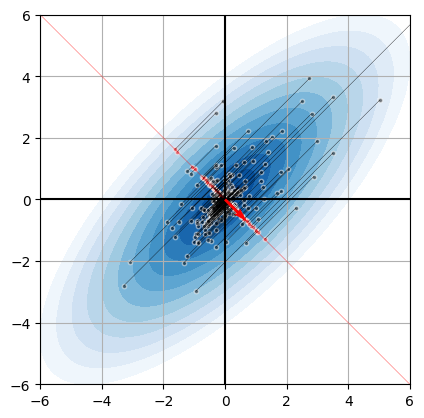

In [50]:
fig, ax = plt.subplots()
# 等高线
plt.contourf(xx1, xx2, mahal_dd,
             cmap='Blues_r', levels=np.linspace(0,6,13))
# 原始数据的散点图
plt.scatter(X_scaled[:,0],X_scaled[:,1],
            s = 38, edgecolor = 'w', alpha = 0.5,
            marker = '.', color = 'k')
# 绘制质心
plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',
         color = 'k',
         markersize = 18)
# 原始数据在v2的投影
plt.scatter(z2_2D[:,0],z2_2D[:,1],
            s = 38, edgecolor = 'w', alpha = 0.5,
            marker = '.', color = 'r')
# 连接数据点
plt.plot(([i for (i,j) in z2_2D], [i for (i,j) in X_scaled]),
         ([j for (i,j) in z2_2D], [j for (i,j) in X_scaled]),
         c='k', lw = 0.25)

draw_vector(v2,'r')
ax.plot(x1_array,x1_array*v2[1]/v2[0], 'r', lw = 0.25)

ax.axvline(x = 0, c = 'k')
ax.axhline(y = 0, c = 'k')
ax.grid('off')
ax.set_aspect('equal', adjustable='box')
ax.set_xbound(lower = -6, upper = 6)
ax.set_ybound(lower = -6, upper = 6)

In [57]:
V

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

In [52]:
Z = X_scaled @ V
# 计算协方差矩阵
COV = EmpiricalCovariance().fit(Z)

In [54]:
Z.shape

(248, 2)

In [55]:
COV

EmpiricalCovariance()

计算马氏距离

In [56]:
mahal_sq_Xc = COV.mahalanobis(xx12)
mahal_sq_dd = mahal_sq_Xc.reshape(xx1.shape)
mahal_dd = np.sqrt(mahal_sq_dd)

#绘制图像

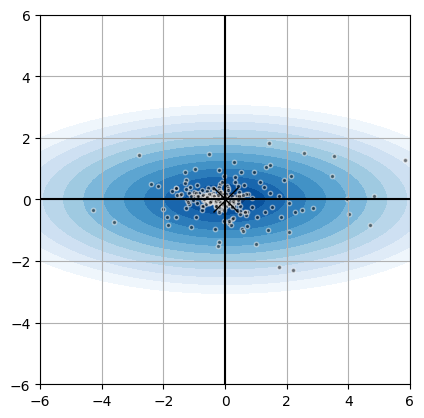

In [58]:
fig, ax = plt.subplots()

# 等高线
plt.contourf(xx1, xx2, mahal_dd,
             cmap='Blues_r', levels=np.linspace(0,6,13))
# 散点图
# Z = X_scaled @ V V为协方差矩阵
plt.scatter(Z[:,0],Z[:,1],
            s = 38, edgecolor = 'w', alpha = 0.5,
            marker = '.', color = 'k')
# 绘制质心
plt.plot(X_scaled[:,0].mean(),X_scaled[:,1].mean(),
         marker = 'x',
         color = 'k',
         markersize = 18)

ax.axvline(x = 0, c = 'k')
ax.axhline(y = 0, c = 'k')
ax.grid('off')
ax.set_aspect('equal', adjustable='box')
ax.set_xbound(lower = -6, upper = 6)
ax.set_ybound(lower = -6, upper = 6)